In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import nnls
import matplotlib.pyplot as plt
import itertools
rng = np.random.default_rng(seed=None)

In [2]:
def generate_mixture_spectra(
    df,
    wavelength_col="Wavelength",
    combination_sizes=(2, 3),
    n_mixtures_per_combination=5,
    random_state=42
):
    """
    df: DataFrame with one wavelength column and one column per pure spectrum.
        Example columns: ['Wavelength', 'Diatom_Ptricornutum', ...]
    wavelength_col: name of the wavelength column.
    combination_sizes: tuple with sizes of combinations (e.g. (1, 2, 3, 4)).
        - 1 means single-species "mixtures" (i.e. just that pure spectrum again).
    n_mixtures_per_combination: number of random weightings per given combination.
    random_state: seed for reproducibility.

    Returns:
        mixtures_df: DataFrame with:
            - the wavelength column
            - one column per pure spectrum (copied from df)
            - additional columns for artificial mixtures
        weights_df: DataFrame that stores the weights used for each mixture column
            (so you know the exact composition).
    """
    rng = np.random.default_rng(random_state)

    # All species columns
    spectrum_cols = [c for c in df.columns if c != wavelength_col]

    # To store composition (weights) for each mixture column
    weights_records = []

    new_mixtures_dict = {}

    for k in combination_sizes:
        # All k-element combinations of the spectrum columns
        for comb in itertools.combinations(spectrum_cols, k):
            comb_name_base = "_".join(comb)

            for m in range(n_mixtures_per_combination):
                # Random non-negative weights that sum to 1
                weights = rng.dirichlet(np.ones(k))

                # Linear combination: mix = sum_i w_i * spectrum_i
                mix_spectrum = np.zeros(len(df))
                for col, w in zip(comb, weights):
                    mix_spectrum += w * df[col].values

                # Unique column name for this mixture
                mix_col_name = f"mix{k}_{comb_name_base}_{m}"

                new_mixtures_dict[mix_col_name] = mix_spectrum

                # Store the weights and which species were used
                record = {"mixture_name": mix_col_name}
                for col, w in zip(comb, weights):
                    record[col] = w
                weights_records.append(record)

    new_mixtures_df = pd.DataFrame(new_mixtures_dict)
    mixtures_df = pd.concat([df, new_mixtures_df], axis=1)

    weights_df = pd.DataFrame(weights_records).fillna(0.0)

    return mixtures_df, weights_df

In [3]:
df = pd.read_excel('Spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs
wavelength = df['Wavelength']

# this array serves as the 'basis function' for the NNLS 
abs_spectra = df.iloc[:, 1:].to_numpy().T # (n_wavelengths, n_species)

mixture, weights = generate_mixture_spectra(df, combination_sizes=(7, 8,9), n_mixtures_per_combination=100)
mixture, weights = mixture.to_numpy(), weights.to_numpy()
# need to cut out pure spectra and wavelength columns
mixture, weights = mixture[:,10:], weights[:,1:]

In [4]:
print(mixture.shape)
print(abs_spectra.T.shape)
print(weights.shape)

(451, 4600)
(451, 9)
(4600, 9)


In [5]:
# #test with a polynomial fit
# y = df["Chlamydomonas_Cpriscuii"].to_numpy()


# # fit smooth polynomial baseline
# coeff = np.polyfit(x, y, deg=2)

# baseline = np.polyval(coeff, x)

# # subtract baseline
# y_corrected = y - baseline

# import matplotlib.ticker as ticker

# fig, ax = plt.subplots(figsize=(10,5))

# ax.plot(wavelength, y, label="measured")
# ax.plot(wavelength, y_corrected, label="corrected")

# ax.legend()

# # Fine grid to make out peaks
# ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
# ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
# ax.yaxis.set_major_locator(ticker.MultipleLocator(0.01))
# ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.002))


# ax.grid(which='major', linestyle='-', alpha=0.7)
# ax.grid(which='minor', linestyle='-', alpha=0.4)

# # Prevent crowded x labels
# ax.tick_params(axis='x', labelrotation=0)

# plt.tight_layout()
# plt.show()

In [6]:
noise = rng.normal(0, 1, size = mixture.shape)
# add 10% noise
mixture_noisy = mixture + 0.1 * noise

In [7]:
# NNLS - scipy algorithm
estimated_conc = np.array([nnls(abs_spectra.T, mixture_noisy[:, i])[0] for i in range(mixture_noisy.shape[1])])

In [9]:
# transfer into floats
estimated_conc = np.array(estimated_conc, dtype=float)
weights = np.array(weights, dtype=float)
difference = np.abs(estimated_conc - weights)

# find the mean and std of difference per mixture
mean_accuracy_per_mixture = np.mean(difference, axis =1)
std_accuracy_per_mixture = np.std(difference, axis = 1)

0.9606349809658159


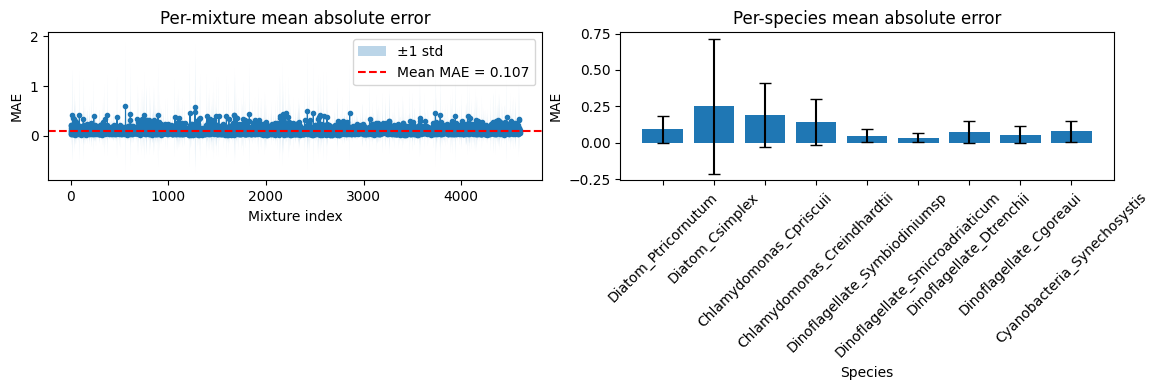

In [10]:
# plot for clarity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mean_accuracy_per_mixture, marker='o', markersize=3, linewidth=0.8)
axes[0].fill_between(
    range(len(mean_accuracy_per_mixture)),
    mean_accuracy_per_mixture - std_accuracy_per_mixture,
    mean_accuracy_per_mixture + std_accuracy_per_mixture,
    alpha=0.3, label='±1 std'
)
axes[0].axhline(np.mean(mean_accuracy_per_mixture), color='red', linestyle='--', label=f'Mean MAE = {np.mean(mean_accuracy_per_mixture):.3f}')
axes[0].set_xlabel("Mixture index")
axes[0].set_ylabel("MAE")
axes[0].set_title("Per-mixture mean absolute error")
axes[0].legend()


species_names = df.columns[1:].tolist()

# mean and std of difference per specie (most insightful)
per_species_mae = np.mean(difference, axis=0)
per_species_std = np.std(difference, axis=0)
# sums up to 1?
print(np.sum(per_species_mae))

axes[1].bar(species_names, per_species_mae, yerr=per_species_std, capsize=4)
axes[1].set_xlabel("Species")
axes[1].set_ylabel("MAE")
axes[1].set_title("Per-species mean absolute error")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# for scattering, just add a Mie scattering spectra as a 'pure' spectra. 
# The NNLS will then just use this to estimate the scattering

In [12]:

def conc_from_weights(mixture_weights):
    
    """
    mixture_weights: weights for one mixture

    Returns: 1-D arrays with
        abs_Chla: absorbances of each strain at 662 nm 
        Chla_cell: Chlorophyll a per cell in kg
        c_Chla: Chla concentration
        cells_per_volume: cells of each strain per litre
    """
    epsilon_chla = 78.75e5  # extinction coefficient of Chl a [l/(mol*m)]
    l = 1e-2            # cuvette path length, assumed to be standard 1 cm

    # normalization of the spectra (from df so wavelengths and labels can be used later)
    species_names = df.columns.drop("Wavelength")
    df_norm = df.copy()
    df_norm[species_names] = (df_norm[species_names]/ df_norm[species_names].max(axis=0))

    # select Chl a region (from literature)
    mask = (wavelength >= 630) & (wavelength <= 700)
    peak_idx = df_norm.loc[mask, species_names].idxmax(axis=0)

    # peak_wavelength = df_norm.loc[peak_idx, "Wavelength"]
    peak_absorbance = pd.Series(index=species_names, dtype=float)
    peak_wavelength = pd.Series(index=species_names, dtype=float)

    for species in species_names:
        peak_idx = df_norm.loc[mask, species].idxmax()

        peak_wavelength[species] = df_norm.loc[peak_idx, "Wavelength"]
        peak_absorbance[species] = df_norm.loc[peak_idx, species]

    abs_Chla = mixture_weights * peak_absorbance
    

    # Provide Chl a (for Chlamydomonas_Cpriscuii: Chl b, Chl a: Chl b ~ 1 here) per cell, 
    # in moles/cell (molecular weight Chla: 893.509 g/mol, Chl b: 907.49(893.509) more robust, against re-arrangement of the columns in this case
    # ideally, Chl a per cell per strain (environment-dependent) would be saved along with the non-mixed absorption spectra

    Chla_cell = pd.Series(
        {
            "Diatom_Ptricornutum": 0.3,
            "Diatom_Csimplex": 1.285,
            "Chlamydomonas_Cpriscuii": 2.17*(893.509)/(893.509),
            "Chlamydomonas_Creindhardtii": 2.2,
            "Dinoflagellate_Symbiodiniumsp": 7,
            "Dinoflagellate_Smicroadriaticum": 16,
            "Dinoflagellate_Dtrenchii": 6,
            "Dinoflagellate_Cgoreaui": 7.25,
            "Cyanobacteria_Synechosystis": 0.008,
        },
        dtype=float,
    ) * 1e-12 * (893.509)**(-1) # conversion of units from g to moles per cell

    # name match check
    missing_in_df = Chla_cell.index.difference(abs_Chla.index)
    missing_in_chla = abs_Chla.index.difference(Chla_cell.index)

    if len(missing_in_df) or len(missing_in_chla):
        raise ValueError(
            f"Name mismatch.\n"
            f"In Chla_cell but not df: {list(missing_in_df)}\n"
            f"In df but not Chla_cell: {list(missing_in_chla)}"
        )

    # align by strain name, redundant here, but important if column order is changed compared to our original table
    abs_Chla = abs_Chla[Chla_cell.index]
    

    # concentration of Chl a from Beer-Lambert law
    c_Chla = abs_Chla / (epsilon_chla * l)
   

    # actual strain cells per volume
    cells_per_volume = c_Chla *1e3 / Chla_cell
    return (
    peak_wavelength,
    peak_absorbance,
    abs_Chla,
    Chla_cell,
    c_Chla,
    cells_per_volume,
    )



# Example for an output of one mixture (field measurement situation)
(
    peak_wavelength_example,
    peak_absorbance_example,
    abs_Chla_example,
    Chla_cell_example,
    c_Chla_example,
    cells_per_volume_example,
) = conc_from_weights(weights[1, :])

results = pd.DataFrame({
    "Peak wavelength [nm]": peak_wavelength_example,
    "Peak absorbance": peak_absorbance_example,
    "Weighted absorbance": abs_Chla_example,
    "Chl a (C. Cpriscuii: Chl b) per cell in kg": Chla_cell_example,
    "Chla concentration": c_Chla_example,
    "Estimated cells per litre": cells_per_volume_example,
})

print("\n=== Strain concentrations ===\n")
print(results)


=== Strain concentrations ===

                                 Peak wavelength [nm]  Peak absorbance  \
Diatom_Ptricornutum                             674.0         0.733964   
Diatom_Csimplex                                 674.0         0.630645   
Chlamydomonas_Cpriscuii                         679.0         0.119158   
Chlamydomonas_Creindhardtii                     675.0         0.685132   
Dinoflagellate_Symbiodiniumsp                   674.0         0.768752   
Dinoflagellate_Smicroadriaticum                 675.0         0.583423   
Dinoflagellate_Dtrenchii                        674.0         0.628848   
Dinoflagellate_Cgoreaui                         674.0         0.534396   
Cyanobacteria_Synechosystis                     679.0         0.475611   

                                 Weighted absorbance  \
Diatom_Ptricornutum                         0.304619   
Diatom_Csimplex                             0.006643   
Chlamydomonas_Cpriscuii                     0.016566   
Chl

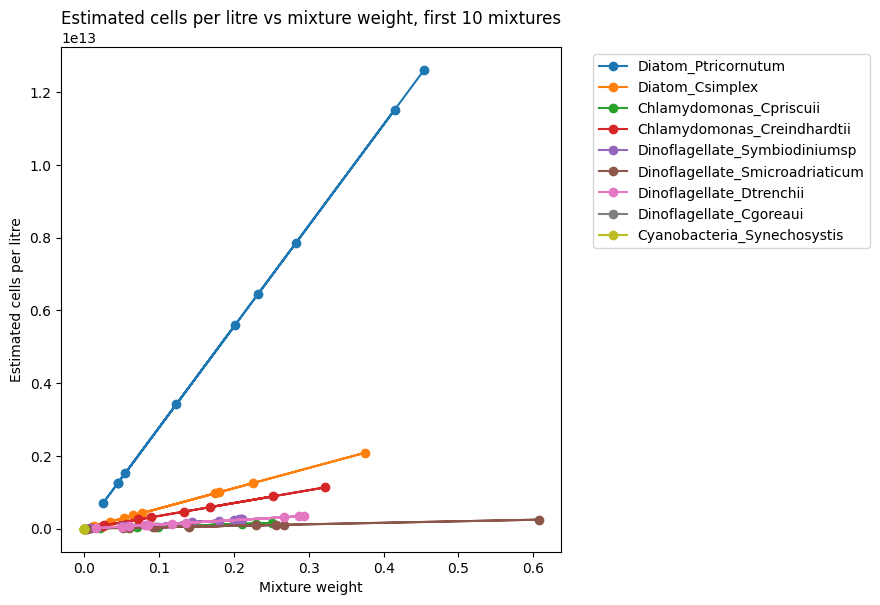

In [14]:
# Plot cells per litre vs. weights for first 10 mixtures as sanity check
n_mixtures = 10 # Number of mixtures to plot

strain_names = [
    "Diatom_Ptricornutum",
    "Diatom_Csimplex",
    "Chlamydomonas_Cpriscuii",
    "Chlamydomonas_Creindhardtii",
    "Dinoflagellate_Symbiodiniumsp",
    "Dinoflagellate_Smicroadriaticum",
    "Dinoflagellate_Dtrenchii",
    "Dinoflagellate_Cgoreaui",
    "Cyanobacteria_Synechosystis",
]

all_results = []

for i in range(n_mixtures):
    
    mixture_weights = pd.Series(weights[i, :], index=strain_names)
    
    peak_wavelength, peak_absorbance,abs_Chla, Chla_cell, c_Chla, cells_per_volume = conc_from_weights(mixture_weights)

    temp = pd.DataFrame({
        "Mixture": i,
        "Strain": strain_names,
        "Weight": mixture_weights,
        "Chla_concentration": c_Chla,
        "Cells_per_litre": cells_per_volume,
    })

    all_results.append(temp)

plot_df = pd.concat(all_results, ignore_index=True)

plt.figure(figsize=(9, 6))

for strain in strain_names:
    subset = plot_df[plot_df["Strain"] == strain]

    plt.plot(
        subset["Weight"],
        subset["Cells_per_litre"],
        marker="o",
        label=strain
    )

plt.xlabel("Mixture weight")
plt.ylabel("Estimated cells per litre")
plt.title("Estimated cells per litre vs mixture weight, first 10 mixtures")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()